# House Prices Project

**Dataset**: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

**Goal**: Predict the sale price of houses using statistical and machine learning methods.


---
## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Add your additional imports as needed
# from sklearn...
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations
import statsmodels.formula.api as smf
# import torch

pd.set_option('display.max_columns', 100)
%matplotlib inline

---
## Load Data

In [2]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

print(f'Training set: {train.shape[0]} rows, {train.shape[1]} columns')
print(f'Test set: {test.shape[0]} rows, {test.shape[1]} columns')

train.head()

Training set: 1460 rows, 81 columns
Test set: 1459 rows, 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [45]:
# Set a pink-themed style
pink_main = '#FF69B4'
pink_dark = '#FF1493'
pink_light = '#FFB6C1'
pink_pale = '#FFC0CB'
pink_accent = "#6D000F"

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


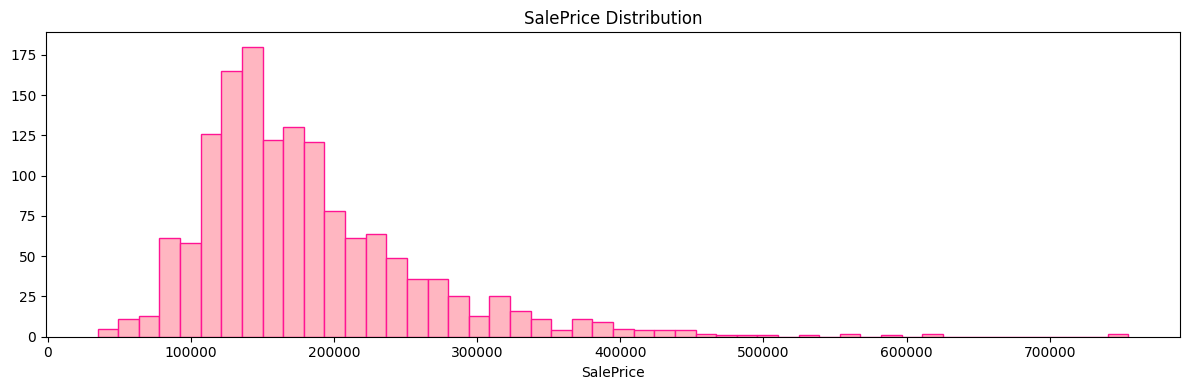

Skewness: 1.883


In [46]:
# Explore the target variable
print(train['SalePrice'].describe())

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.hist(train['SalePrice'], bins=50, edgecolor=pink_dark, color=pink_light)
axes.set_title('SalePrice Distribution')
axes.set_xlabel('SalePrice')
plt.tight_layout()
plt.show()

print(f'Skewness: {train["SalePrice"].skew():.3f}')

The data is heavily skewed, what kind of transformation can we apply to make it more normal? 

count    1460.000000
mean       12.024057
std         0.399449
min        10.460271
25%        11.775105
50%        12.001512
75%        12.273736
max        13.534474
Name: SalePriceLog, dtype: float64


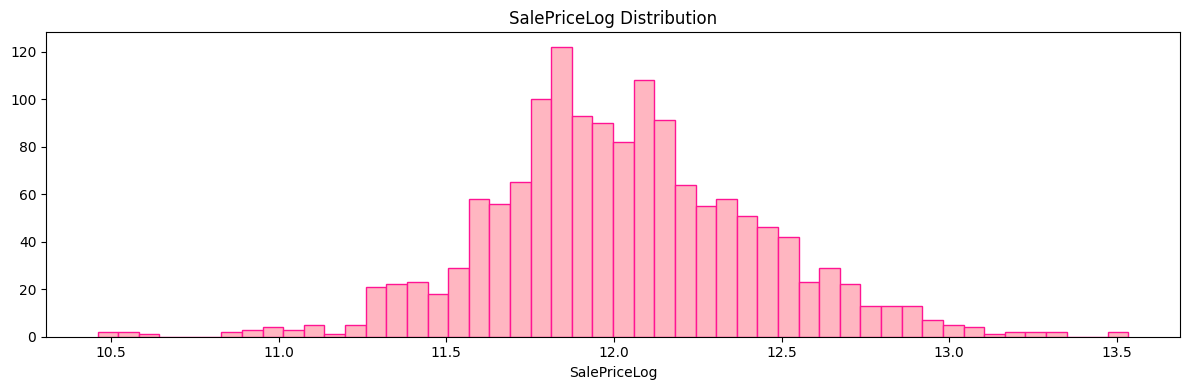

Skewness: 0.121


In [47]:
# Apply a log transformation so y' = log(price + 1) (+1 for safety/robustness)
# Then we can interpret coefficients as percentage changes instead of absolute price changes

df = train.copy()
df["SalePriceLog"] = np.log1p(df["SalePrice"])

print(df['SalePriceLog'].describe())

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.hist(df['SalePriceLog'], bins=50, edgecolor=pink_dark, color=pink_light)
axes.set_title('SalePriceLog Distribution')
axes.set_xlabel('SalePriceLog')
plt.tight_layout()
plt.show()

print(f'Skewness: {df["SalePriceLog"].skew():.3f}')

In [5]:
# Explore missing values
(df.isna().sum()[df.isna().sum() > 0] / len(df)).sort_values(ascending=False) * 100

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtCond         2.534247
BsmtQual         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [6]:
# Let's clean up!
# Assume no data about pool -> no pool, and same for misc, alley and fence
df["PoolQC"] = df["PoolQC"].fillna("NA")
df["MiscFeature"] = df["MiscFeature"].fillna("NA")
df["Alley"] = df["Alley"].fillna("NA")
df["Fence"] = df["Fence"].fillna("NA")

# Assume no data about masonry area -> area = 0
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
# If masonry area is 0, veneer type should be none
df.loc[(df["MasVnrArea"] == 0) & (df["MasVnrType"].isna()), "MasVnrType"] = "None"
# For any with masonry area > 0 but veneer type NaN (4 rows) -> fill with most common veneer type
df["MasVnrType"] = df["MasVnrType"].fillna(df.loc[df["MasVnrArea"] > 0, "MasVnrType"].mode()[0])

# No fireplaces -> fireplace quality is NA
df.loc[(df["Fireplaces"] == 0) & (df["FireplaceQu"].isna()), "FireplaceQu"] = "NA"

# Same treatment for garage
df.loc[(df["GarageArea"] == 0) & (df["GarageFinish"].isna()), "GarageFinish"] = "NA"
df.loc[(df["GarageArea"] == 0) & (df["GarageQual"].isna()), "GarageQual"] = "NA"
df.loc[(df["GarageArea"] == 0) & (df["GarageType"].isna()), "GarageType"] = "NA"
df.loc[(df["GarageArea"] == 0) & (df["GarageCond"].isna()), "GarageCond"] = "NA"
# Add a separate column for garage/no garage (maybe we don't need this)
df["HasGarage"] = df["GarageYrBlt"].notna().astype(int)
# Set year built to 0 if no garage
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

# Again for basement: no basement square feet -> no basement
df.loc[(df["TotalBsmtSF"] == 0), ["BsmtFinType1", "BsmtFinType2", "BsmtExposure", "BsmtQual", "BsmtCond"]] = "NA"
# Deal with any leftover missing values
df[["BsmtFinType2", "BsmtExposure"]] = df[["BsmtFinType2", "BsmtExposure"]].fillna("NA")

# Set missing lot frontage to the neighbourhood median
df["LotFrontage"] = df["LotFrontage"].fillna(
    df.groupby("Neighborhood")["LotFrontage"].transform("median")
)

# Fill in electrical with most frequent value
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

# Just because 'NA' is confusing, let's rename it to 'None'
df = df.replace("NA", "None")

In [7]:
# Check everything is clean
(df.isna().sum()[df.isna().sum() > 0] / len(df)).sort_values(ascending=False) * 100

Series([], dtype: float64)

---
## Part 1: Classical Statistical Inference

Apply basic statistical methods to explore the data:
- **Sample mean and variance** of `SalePrice` and key features
- **Confidence intervals** for the mean SalePrice
- **Hypothesis testing** — e.g. is the mean SalePrice significantly different from \$180,000? Is the distribution of the transformed `SalePrice` normal (Shapiro-Wilk)?
- Visualize distributions and support your conclusions with plots

In [ ]:
# =============================================================================
# Part 1: Classical Statistical Inference
# =============================================================================

# --- 1.1 Sample Mean and Variance of SalePrice ---
print("=" * 60)
print("1.1 Sample Mean and Variance")
print("=" * 60)

sale_price = df["SalePrice"]
sale_price_log = df["SalePriceLog"]

n = len(sale_price)
mean_price = sale_price.mean()
var_price = sale_price.var(ddof=1)
std_price = sale_price.std(ddof=1)

mean_log = sale_price_log.mean()
var_log = sale_price_log.var(ddof=1)
std_log = sale_price_log.std(ddof=1)

print(f"SalePrice:    n={n}, mean=${mean_price:,.2f}, var={var_price:,.2f}, std=${std_price:,.2f}")
print(f"SalePriceLog: n={n}, mean={mean_log:.4f}, var={var_log:.4f}, std={std_log:.4f}")

key_features = ["GrLivArea", "TotalBsmtSF", "LotArea", "GarageArea", "YearBuilt"]
summary_stats = df[key_features].agg(["mean", "var", "std", "median", "min", "max"]).T
summary_stats.columns = ["Mean", "Variance", "Std Dev", "Median", "Min", "Max"]
print("\nKey Numerical Features - Summary Statistics:")
print(summary_stats.round(2))

1.1 Sample Mean and Variance
SalePrice:    n=1460, mean=$180,921.20, var=6,311,111,264.30, std=$79,442.50
SalePriceLog: n=1460, mean=12.0241, var=0.1596, std=0.3994

Key Numerical Features - Summary Statistics:
                 Mean     Variance  Std Dev  Median     Min       Max
GrLivArea     1515.46    276129.63   525.48  1464.0   334.0    5642.0
TotalBsmtSF   1057.43    192462.36   438.71   991.5     0.0    6110.0
LotArea      10516.83  99625649.65  9981.26  9478.5  1300.0  215245.0
GarageArea     472.98     45712.51   213.80   480.0     0.0    1418.0
YearBuilt     1971.27       912.22    30.20  1973.0  1872.0    2010.0


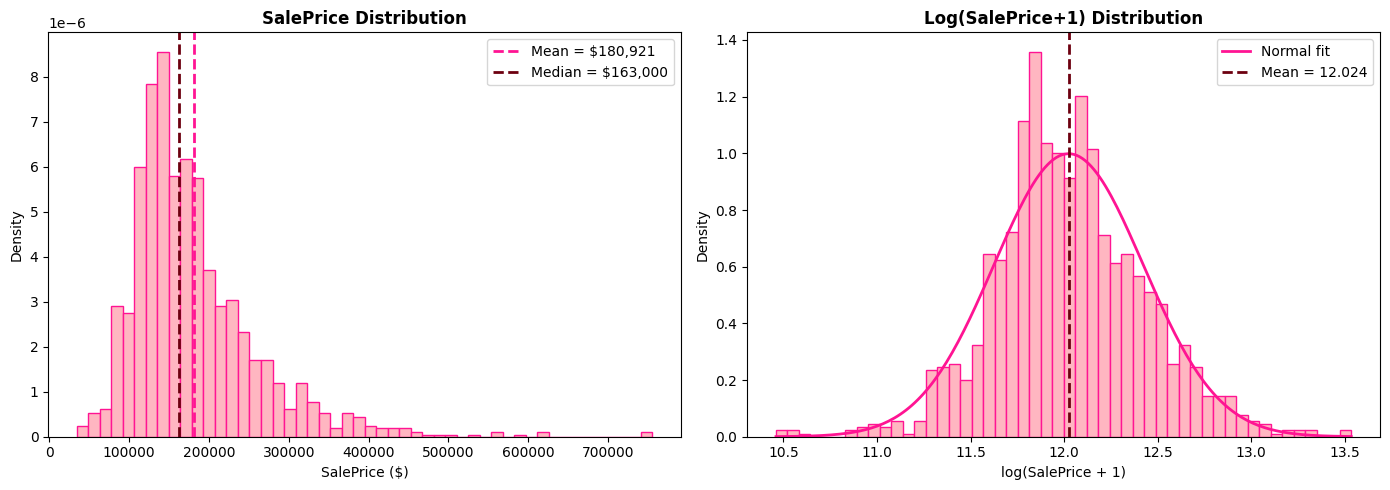

In [21]:
# --- Visualization: distributions of SalePrice and log-transformed ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sale_price, bins=50, edgecolor=pink_dark, color=pink_light, density=True)
axes[0].axvline(mean_price, color=pink_dark, linestyle='--', linewidth=2, label=f'Mean = ${mean_price:,.0f}')
axes[0].axvline(sale_price.median(), color=pink_accent, linestyle='--', linewidth=2, label=f'Median = ${sale_price.median():,.0f}')
axes[0].set_title('SalePrice Distribution', fontweight='bold')
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].hist(sale_price_log, bins=50, edgecolor=pink_dark, color=pink_light, density=True)
x_norm = np.linspace(sale_price_log.min(), sale_price_log.max(), 200)
axes[1].plot(x_norm, stats.norm.pdf(x_norm, mean_log, std_log), color=pink_dark, lw=2, label='Normal fit')
axes[1].axvline(mean_log, color=pink_accent, linestyle='--', linewidth=2, label=f'Mean = {mean_log:.3f}')
axes[1].set_title('Log(SalePrice+1) Distribution', fontweight='bold')
axes[1].set_xlabel('log(SalePrice + 1)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

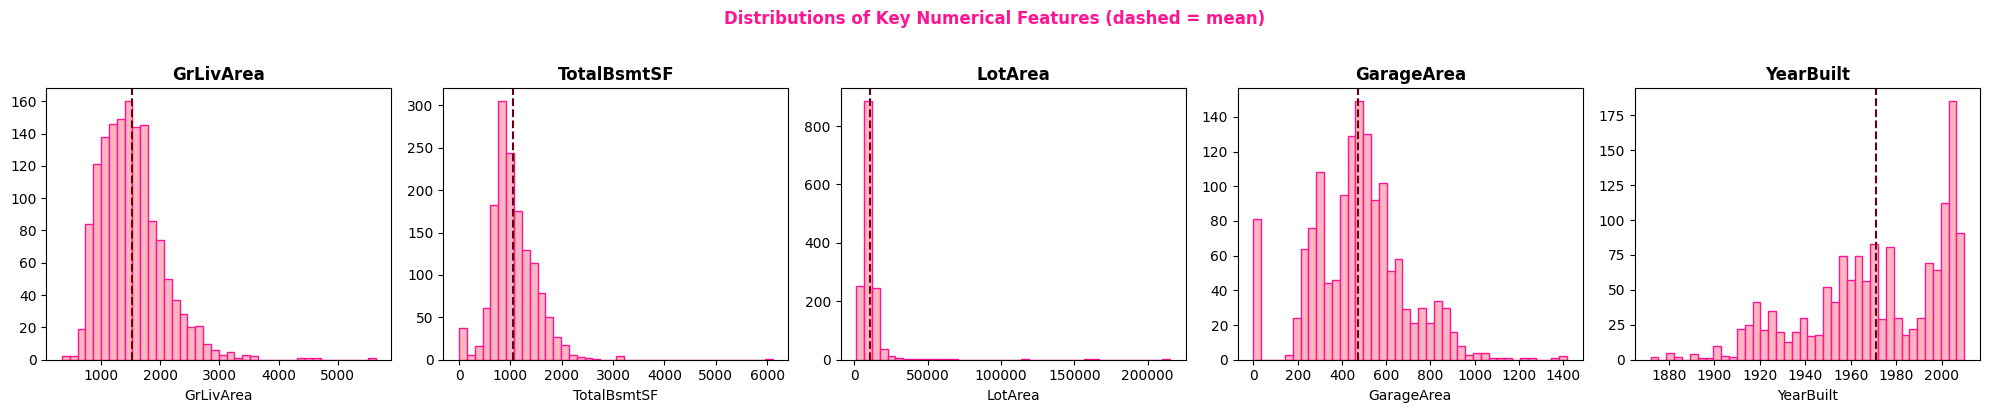

In [48]:
# --- Visualization: key features distributions ---
fig, axes = plt.subplots(1, len(key_features), figsize=(4 * len(key_features), 4))
for i, feat in enumerate(key_features):
    axes[i].hist(df[feat], bins=40, edgecolor=pink_dark, color=pink_light)
    axes[i].axvline(df[feat].mean(), color=pink_accent, linestyle='--', linewidth=1.5)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel(feat)
plt.suptitle("Distributions of Key Numerical Features (dashed = mean)", y=1.02, fontweight='bold', color=pink_dark)
plt.tight_layout()
plt.show()

In [23]:
# =============================================================================
# --- 1.2 Confidence Intervals ---
# =============================================================================
print("=" * 60)
print("1.2 Confidence Intervals")
print("=" * 60)

alpha = 0.05

se_price = std_price / np.sqrt(n)
t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
ci_price = (mean_price - t_crit * se_price, mean_price + t_crit * se_price)
print(f"\n95% CI for mean SalePrice (t-interval):")
print(f"  ({ci_price[0]:,.2f}, {ci_price[1]:,.2f})")

se_log = std_log / np.sqrt(n)
ci_log = (mean_log - t_crit * se_log, mean_log + t_crit * se_log)
print(f"\n95% CI for mean log(SalePrice+1) (t-interval):")
print(f"  ({ci_log[0]:.4f}, {ci_log[1]:.4f})")

ci_log_dollar = (np.expm1(ci_log[0]), np.expm1(ci_log[1]))
print(f"  Back-transformed to dollars: (${ci_log_dollar[0]:,.2f}, ${ci_log_dollar[1]:,.2f})")

chi2_lower = stats.chi2.ppf(alpha / 2, df=n - 1)
chi2_upper = stats.chi2.ppf(1 - alpha / 2, df=n - 1)
ci_var = ((n - 1) * var_price / chi2_upper, (n - 1) * var_price / chi2_lower)
print(f"\n95% CI for SalePrice variance (chi-squared):")
print(f"  ({ci_var[0]:,.2f}, {ci_var[1]:,.2f})")

print(f"\n95% Confidence Intervals for Key Feature Means:")
ci_table = []
for feat in key_features:
    feat_mean = df[feat].mean()
    feat_se = df[feat].std(ddof=1) / np.sqrt(n)
    ci_lo = feat_mean - t_crit * feat_se
    ci_hi = feat_mean + t_crit * feat_se
    ci_table.append({"Feature": feat, "Mean": feat_mean, "CI Lower": ci_lo, "CI Upper": ci_hi})
ci_df = pd.DataFrame(ci_table).set_index("Feature")
print(ci_df.round(2))

1.2 Confidence Intervals

95% CI for mean SalePrice (t-interval):
  (176,842.84, 184,999.55)

95% CI for mean log(SalePrice+1) (t-interval):
  (12.0036, 12.0446)
  Back-transformed to dollars: ($163,332.73, $170,170.83)

95% CI for SalePrice variance (chi-squared):
  (5,877,056,095.66, 6,795,343,509.17)

95% Confidence Intervals for Key Feature Means:
                 Mean  CI Lower  CI Upper
Feature                                  
GrLivArea     1515.46   1488.49   1542.44
TotalBsmtSF   1057.43   1034.91   1079.95
LotArea      10516.83  10004.42  11029.24
GarageArea     472.98    462.00    483.96
YearBuilt     1971.27   1969.72   1972.82


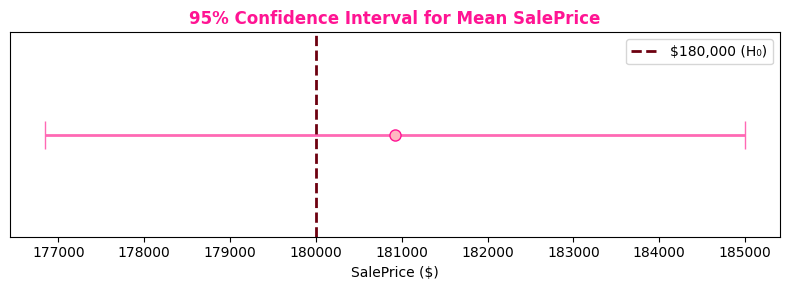

In [49]:
# --- Visualization: CI for SalePrice ---
fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(mean_price, 0, xerr=t_crit * se_price, fmt='o', color=pink_dark,
            capsize=10, markersize=8, linewidth=2, markerfacecolor=pink_light,
            markeredgecolor=pink_dark, ecolor=pink_main)
ax.axvline(180000, color=pink_accent, linestyle='--', linewidth=2, label='$180,000 (H₀)')
ax.set_yticks([])
ax.set_xlabel('SalePrice ($)')
ax.set_title('95% Confidence Interval for Mean SalePrice', fontweight='bold', color=pink_dark)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# --- 1.3 Hypothesis Testing ---
# =============================================================================
print("=" * 60)
print("1.3 Hypothesis Testing")
print("=" * 60)

# --- Test 1: Is mean SalePrice significantly different from $180,000? ---
mu_0 = 180000
t_stat = (mean_price - mu_0) / se_price
p_value_ttest = 2 * stats.t.sf(abs(t_stat), df=n - 1)

print(f"\nTest 1: H₀: μ = ${mu_0:,} vs H₁: μ ≠ ${mu_0:,}")
print(f"  Sample mean: ${mean_price:,.2f}")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value_ttest:.6f}")
print(f"  Decision at α=0.05: {'Reject H₀' if p_value_ttest < alpha else 'Fail to reject H₀'}")

t_stat_scipy, p_val_scipy = stats.ttest_1samp(sale_price, mu_0)
print(f"  (scipy verification: t={t_stat_scipy:.4f}, p={p_val_scipy:.6f})")

1.3 Hypothesis Testing

Test 1: H₀: μ = $180,000 vs H₁: μ ≠ $180,000
  Sample mean: $180,921.20
  t-statistic: 0.4431
  p-value: 0.657778
  Decision at α=0.05: Fail to reject H₀
  (scipy verification: t=0.4431, p=0.657778)


In [51]:
# --- Test 2: Shapiro-Wilk normality tests ---
if n > 5000:
    sample_sw = sale_price.sample(5000, random_state=42)
else:
    sample_sw = sale_price
sw_stat, sw_p = stats.shapiro(sample_sw)
print(f"Test 2a: Shapiro-Wilk normality test on SalePrice")
print(f"  W-statistic: {sw_stat:.6f}")
print(f"  p-value: {sw_p:.6e}")
print(f"  Decision at α=0.05: {'Reject H₀ (NOT normal)' if sw_p < alpha else 'Fail to reject H₀ (normal)'}")

if n > 5000:
    sample_sw_log = sale_price_log.sample(5000, random_state=42)
else:
    sample_sw_log = sale_price_log
sw_stat_log, sw_p_log = stats.shapiro(sample_sw_log)
print(f"\nTest 2b: Shapiro-Wilk normality test on log(SalePrice+1)")
print(f"  W-statistic: {sw_stat_log:.6f}")
print(f"  p-value: {sw_p_log:.6e}")
print(f"  Decision at α=0.05: {'Reject H₀ (NOT normal)' if sw_p_log < alpha else 'Fail to reject H₀ (normal)'}")


Test 2a: Shapiro-Wilk normality test on SalePrice
  W-statistic: 0.869671
  p-value: 3.206141e-33
  Decision at α=0.05: Reject H₀ (NOT normal)

Test 2b: Shapiro-Wilk normality test on log(SalePrice+1)
  W-statistic: 0.991207
  p-value: 1.149074e-07
  Decision at α=0.05: Reject H₀ (NOT normal)


In [52]:
# --- Test 3: Two-sample t-test: Central Air ---
group_yes = df.loc[df["CentralAir"] == "Y", "SalePrice"]
group_no = df.loc[df["CentralAir"] == "N", "SalePrice"]
t_air, p_air = stats.ttest_ind(group_yes, group_no, equal_var=False)
print(f"Test 3: Welch's t-test — CentralAir=Y vs CentralAir=N on SalePrice")
print(f"  Mean (Yes): ${group_yes.mean():,.2f} (n={len(group_yes)})")
print(f"  Mean (No):  ${group_no.mean():,.2f} (n={len(group_no)})")
print(f"  t-statistic: {t_air:.4f}")
print(f"  p-value: {p_air:.6e}")
print(f"  Decision at α=0.05: {'Reject H₀ (significant difference)' if p_air < alpha else 'Fail to reject H₀'}")

Test 3: Welch's t-test — CentralAir=Y vs CentralAir=N on SalePrice
  Mean (Yes): $186,186.71 (n=1365)
  Mean (No):  $105,264.07 (n=95)
  t-statistic: 17.2678
  p-value: 2.280814e-37
  Decision at α=0.05: Reject H₀ (significant difference)


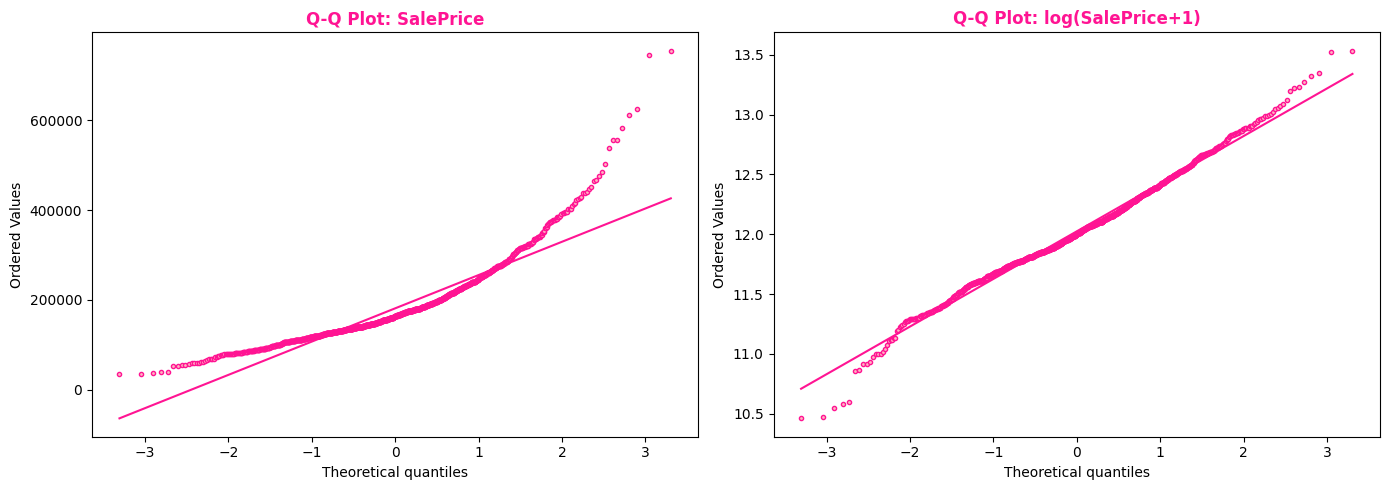

In [53]:
# --- Visualization: QQ plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats.probplot(sale_price, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot: SalePrice", fontweight='bold', color=pink_dark)
axes[0].get_lines()[0].set_markerfacecolor(pink_light)
axes[0].get_lines()[0].set_markeredgecolor(pink_dark)
axes[0].get_lines()[0].set_markersize(3)
axes[0].get_lines()[1].set_color(pink_dark)

stats.probplot(sale_price_log, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: log(SalePrice+1)", fontweight='bold', color=pink_dark)
axes[1].get_lines()[0].set_markerfacecolor(pink_light)
axes[1].get_lines()[0].set_markeredgecolor(pink_dark)
axes[1].get_lines()[0].set_markersize(3)
axes[1].get_lines()[1].set_color(pink_dark)

plt.tight_layout()
plt.show()

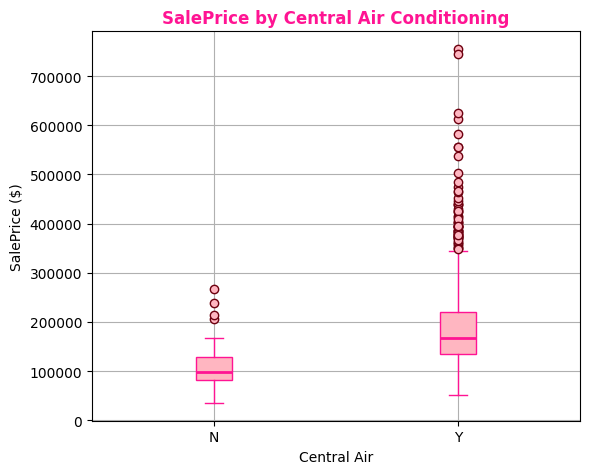

In [54]:
# --- Visualization: Central Air boxplot ---
fig, ax = plt.subplots(figsize=(6, 5))
bp = df.boxplot(column='SalePrice', by='CentralAir', ax=ax,
                patch_artist=True, return_type='dict')
for patch in bp['SalePrice']['boxes']:
    patch.set_facecolor(pink_light)
    patch.set_edgecolor(pink_dark)
for whisker in bp['SalePrice']['whiskers']:
    whisker.set_color(pink_dark)
for cap in bp['SalePrice']['caps']:
    cap.set_color(pink_dark)
for median in bp['SalePrice']['medians']:
    median.set_color(pink_dark)
    median.set_linewidth(2)
for flier in bp['SalePrice']['fliers']:
    flier.set_markerfacecolor(pink_light)
    flier.set_markeredgecolor(pink_accent)
ax.set_title('SalePrice by Central Air Conditioning', fontweight='bold', color=pink_dark)
ax.set_xlabel('Central Air')
ax.set_ylabel('SalePrice ($)')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [55]:
# --- 1.4 Summary Table ---
print("=" * 60)
print("1.4 Summary of Statistical Tests")
print("=" * 60)

summary_tests = pd.DataFrame({
    "Test": [
        "One-sample t-test (μ = $180,000)",
        "Shapiro-Wilk (SalePrice)",
        "Shapiro-Wilk (log SalePrice)",
        "Welch t-test (CentralAir)"
    ],
    "Statistic": [t_stat, sw_stat, sw_stat_log, t_air],
    "p-value": [p_value_ttest, sw_p, sw_p_log, p_air],
    "Reject H₀ (α=0.05)": [
        p_value_ttest < alpha, sw_p < alpha, sw_p_log < alpha,
        p_air < alpha
    ]
})
print(summary_tests.to_string(index=False))

1.4 Summary of Statistical Tests
                            Test  Statistic      p-value  Reject H₀ (α=0.05)
One-sample t-test (μ = $180,000)   0.443073 6.577785e-01               False
        Shapiro-Wilk (SalePrice)   0.869671 3.206141e-33                True
    Shapiro-Wilk (log SalePrice)   0.991207 1.149074e-07                True
       Welch t-test (CentralAir)  17.267773 2.280814e-37                True


---
## Part 2: ANOVA — Finding Significant Features

Use ANOVA to determine which of the following **10 features** have a statistically significant effect on the transformed SalePrice. 

**Given features (10):**

| # | Feature | Levels | Description |
|---|---|---|---|
| 1 | `OverallQual` | 1–10 | Overall material and finish quality |
| 2 | `ExterQual` | Po, Fa, TA, Gd, Ex | Exterior material quality |
| 3 | `BsmtQual` | None, Po, Fa, TA, Gd, Ex | Basement height quality |
| 4 | `KitchenQual` | Po, Fa, TA, Gd, Ex | Kitchen quality |
| 5 | `FireplaceQu` | None, Po, Fa, TA, Gd, Ex | Fireplace quality |
| 6 | `CentralAir` | N, Y | Central air conditioning |
| 7 | `LotShape` | IR3, IR2, IR1, Reg | General shape of property |
| 8 | `LandSlope` | Sev, Mod, Gtl | Slope of property |
| 9 | `MoSold` | 1–12 | Month sold |
| 10 | `YrSold` | 2006–2010 | Year sold |

**Tasks:**
1. Extract these features into a dataframe and run **one-way ANOVA** on each
2. Identify which features are significant (p < 0.05)
3. Run a **two-way ANOVA** to test for interaction effects between pairs of significant features
4. Use **Tukey HSD** post-hoc tests where appropriate
5. Summarize: which features and interactions are significant?

In [35]:
features = ["OverallQual", "ExterQual", "BsmtQual", "KitchenQual", "FireplaceQu", "CentralAir", "LotShape", "LandSlope", "MoSold", "YrSold"]

df_for_anova = df[features + ["SalePriceLog"]]
df_for_anova.head()

,OverallQual,ExterQual,BsmtQual,KitchenQual,FireplaceQu,CentralAir,LotShape,LandSlope,MoSold,YrSold,SalePriceLog
0,7,Gd,Gd,Gd,None,Y,Reg,Gtl,2,2008,12.247699
1,6,TA,Gd,TA,TA,Y,Reg,Gtl,5,2007,12.109016
2,7,Gd,Gd,Gd,TA,Y,IR1,Gtl,9,2008,12.317171
3,7,TA,TA,Gd,Gd,Y,IR1,Gtl,2,2006,11.849405
4,8,Gd,Gd,Gd,TA,Y,IR1,Gtl,12,2008,12.429220


In [36]:
# Run one-way ANOVA on selected features
results = []

for feature in features:
  groups = [group["SalePriceLog"].values for name, group in df_for_anova.groupby(feature)]
  f_stat, p_value = stats.f_oneway(*groups)

  results.append({
      "feature": feature,
      "f_statistic": f_stat,
      "p_value": p_value,
      "num_groups": len(groups)
  })

anova_df = pd.DataFrame(results)
anova_df = anova_df.sort_values("p_value")
anova_df["significant"] = anova_df["p_value"] < 0.05
anova_df

,feature,f_statistic,p_value,num_groups,significant
0,OverallQual,332.166960,0.000000e+00,10,True
1,ExterQual,415.304259,6.930372e-195,4,True
2,BsmtQual,300.392915,2.029970e-188,5,True
3,KitchenQual,393.320922,4.438817e-187,4,True
4,FireplaceQu,131.198588,6.961918e-115,6,True
5,CentralAir,205.666008,9.859878e-44,2,True
6,LotShape,46.728785,7.856720e-29,4,True
7,LandSlope,1.083050,3.388339e-01,3,False
8,MoSold,0.993741,4.496614e-01,12,False
9,YrSold,0.738615,5.656386e-01,5,False


In [37]:
# Show which features are significant according to one-way ANOVA
significant_features = anova_df[anova_df["significant"]]["feature"].tolist()
print(significant_features)

['OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 'CentralAir', 'LotShape']


In [38]:
# Run 2-way ANOVA on pairs of significant features
results = []

for f1, f2 in combinations(significant_features, 2):
    formula = f"SalePriceLog ~ C({f1}) * C({f2})"
    model = smf.ols(formula, data=df_for_anova).fit()
    anova = sm.stats.anova_lm(model, typ=2)

    results.append({
        "feature1": f1,
        "feature2": f2,
        "p_interaction": anova.loc[f"C({f1}):C({f2})", "PR(>F)"]
    })

anova2_df = pd.DataFrame(results).sort_values("p_interaction")
anova2_df["significant"] = anova2_df["p_interaction"] < 0.05
anova2_df

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 22
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance 

,feature1,feature2,p_interaction,significant
0,OverallQual,ExterQual,0.000000e+00,True
3,OverallQual,FireplaceQu,0.000000e+00,True
13,BsmtQual,CentralAir,0.000000e+00,True
9,ExterQual,CentralAir,0.000000e+00,True
18,FireplaceQu,CentralAir,0.000000e+00,True
2,OverallQual,KitchenQual,8.442842e-242,True
1,OverallQual,BsmtQual,6.951414e-222,True
15,KitchenQual,FireplaceQu,8.620148e-112,True
11,BsmtQual,KitchenQual,1.793853e-96,True
6,ExterQual,BsmtQual,3.221320e-90,True


In [39]:
# Check frequency of combinations using contingency table
print(pd.crosstab(df_for_anova["OverallQual"], df_for_anova["KitchenQual"]))
print(pd.crosstab(df_for_anova["FireplaceQu"], df_for_anova["LotShape"]))

KitchenQual  Ex  Fa   Gd   TA
OverallQual                  
1             0   2    0    0
2             0   2    0    1
3             0   3    1   16
4             0  12   10   94
5             8   9   60  320
6             2  10  127  235
7            10   1  244   64
8            30   0  133    5
9            35   0    8    0
10           15   0    3    0
LotShape     IR1  IR2  IR3  Reg
FireplaceQu                    
Ex            11    2    0   11
Fa            12    1    1   19
Gd           147   11    5  217
None         163   15    1  511
Po             6    0    0   14
TA           145   12    3  153


In [40]:
# Run Tukey's HSD on significant features from one-way ANOVA
for feature in significant_features:
    print("\n" + "="*50)
    print(f"Tukey HSD for {feature}")
    print("="*50)

    tukey = pairwise_tukeyhsd(
        endog=df_for_anova["SalePriceLog"],
        groups=df_for_anova[feature],
        alpha=0.05
    )

    print(tukey)


Tukey HSD for OverallQual
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2   0.0266    1.0 -0.6358  0.689  False
     1      3   0.5387 0.0495  0.0005 1.0768   True
     1      4   0.7583 0.0002  0.2409 1.2758   True
     1      5   0.9818    0.0  0.4675 1.4962   True
     1      6   1.1685    0.0   0.654 1.6829   True
     1      7    1.423    0.0  0.9083 1.9376   True
     1      8   1.6984    0.0  1.1822 2.2145   True
     1      9   1.9944    0.0  1.4696 2.5193   True
     1     10   2.1225    0.0  1.5817 2.6633   True
     2      3   0.5121 0.0117  0.0628 0.9613   True
     2      4   0.7318    0.0  0.3074 1.1561   True
     2      5   0.9553    0.0  0.5348 1.3758   True
     2      6   1.1419    0.0  0.7213 1.5625   True
     2      7   1.3964    0.0  0.9755 1.8173   True
     2      8   1.6718    0.0  1.2491 2.0944   True
     2      9   1.9679    0.0  1.5346

---
## Part 3: 2^k Factorial Design

Pick k binary (or binarized) factors from the significant features found in Part 2 and apply a factorial design analysis. For example you could binarize ordinal features into High/Low groups and study their joint effects.

**Tasks:**
- Select k factors (e.g. k=2 or k=3) and define High/Low levels
- Compute group means for all 2^k combinations
- Analyze main effects and interaction effects
- Visualize with interaction plots

In [56]:
# =============================================================================
# Part 3: 2^k Factorial Design (k=3)
# =============================================================================

# Select 3 significant factors from ANOVA (Part 2) and binarize into High/Low
# Factor A: OverallQual — High (>= 7) vs Low (< 7)   [median split]
# Factor B: ExterQual   — High (Ex, Gd) vs Low (TA, Fa)
# Factor C: CentralAir  — Already binary (Y / N)

df["A_OverallQual"] = (df["OverallQual"] >= 7).map({True: "High", False: "Low"})
df["B_ExterQual"] = df["ExterQual"].map({"Ex": "High", "Gd": "High", "TA": "Low", "Fa": "Low"})
df["C_CentralAir"] = df["CentralAir"].map({"Y": "High", "N": "Low"})

print("Factor A (OverallQual — High if >= 7):")
print(df["A_OverallQual"].value_counts())
print(f"\nFactor B (ExterQual — High if Ex/Gd):")
print(df["B_ExterQual"].value_counts())
print(f"\nFactor C (CentralAir — Y=High, N=Low):")
print(df["C_CentralAir"].value_counts())

Factor A (OverallQual — High if >= 7):
A_OverallQual
Low     912
High    548
Name: count, dtype: int64

Factor B (ExterQual — High if Ex/Gd):
B_ExterQual
Low     920
High    540
Name: count, dtype: int64

Factor C (CentralAir — Y=High, N=Low):
C_CentralAir
High    1365
Low       95
Name: count, dtype: int64


In [57]:
# --- Group means for all 2^3 combinations ---
factorial_groups = df.groupby(["A_OverallQual", "B_ExterQual", "C_CentralAir"]).agg(
    Mean_SalePrice=("SalePrice", "mean"),
    Mean_LogPrice=("SalePriceLog", "mean"),
    Count=("SalePrice", "count")
).reset_index()

print("2^3 Factorial Design — Group Means:")
print(factorial_groups.to_string(index=False))

2^3 Factorial Design — Group Means:
A_OverallQual B_ExterQual C_CentralAir  Mean_SalePrice  Mean_LogPrice  Count
         High        High         High   260514.660633      12.425304    442
         High        High          Low   235489.500000      12.360973      2
         High         Low         High   199218.010000      12.168100    100
         High         Low          Low   143625.000000      11.863456      4
          Low        High         High   173357.063830      12.038994     94
          Low        High          Low   112950.000000      11.633501      2
          Low         Low         High   140987.673525      11.828445    729
          Low         Low          Low   100329.977011      11.451549     87


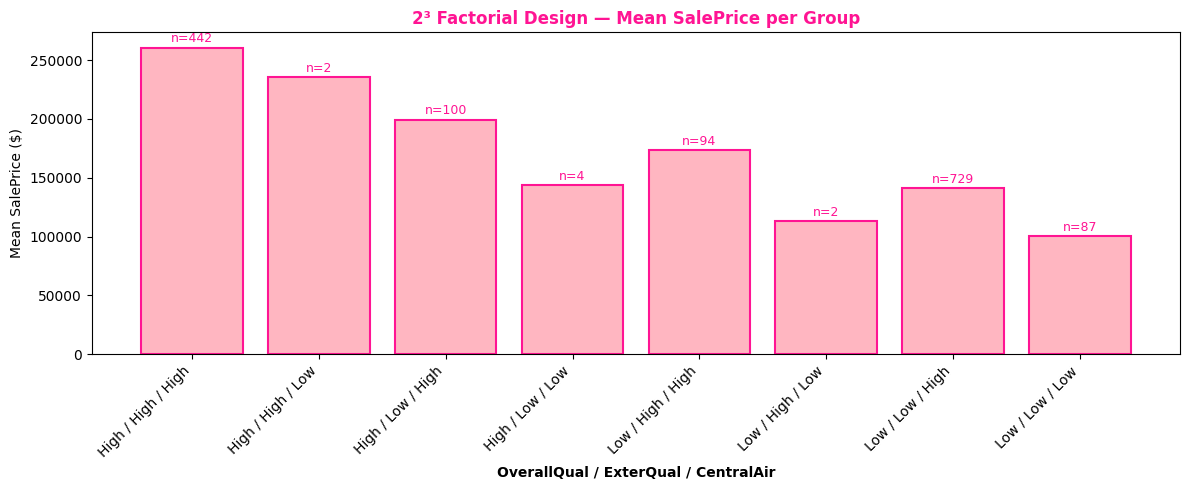

In [58]:
# --- Visualization: group means bar chart ---
factorial_groups["Label"] = (
    factorial_groups["A_OverallQual"] + " / " +
    factorial_groups["B_ExterQual"] + " / " +
    factorial_groups["C_CentralAir"]
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(factorial_groups["Label"], factorial_groups["Mean_SalePrice"],
              color=pink_light, edgecolor=pink_dark, linewidth=1.5)
ax.set_xlabel("OverallQual / ExterQual / CentralAir", fontweight='bold')
ax.set_ylabel("Mean SalePrice ($)")
ax.set_title("2³ Factorial Design — Mean SalePrice per Group", fontweight='bold', color=pink_dark)
plt.xticks(rotation=45, ha='right')

for bar, count in zip(bars, factorial_groups["Count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'n={count}', ha='center', va='bottom', fontsize=9, color=pink_dark)

plt.tight_layout()
plt.show()

In [59]:
# --- Main Effects ---
print("=" * 60)
print("Main Effects")
print("=" * 60)

main_A = df.loc[df["A_OverallQual"] == "High", "SalePrice"].mean() - \
         df.loc[df["A_OverallQual"] == "Low", "SalePrice"].mean()

main_B = df.loc[df["B_ExterQual"] == "High", "SalePrice"].mean() - \
         df.loc[df["B_ExterQual"] == "Low", "SalePrice"].mean()

main_C = df.loc[df["C_CentralAir"] == "High", "SalePrice"].mean() - \
         df.loc[df["C_CentralAir"] == "Low", "SalePrice"].mean()

print(f"  Main Effect A (OverallQual): ${main_A:,.2f}")
print(f"  Main Effect B (ExterQual):   ${main_B:,.2f}")
print(f"  Main Effect C (CentralAir):  ${main_C:,.2f}")
print(f"\n  Interpretation:")
print(f"  - Going from Low to High OverallQual increases price by ~${main_A:,.0f}")
print(f"  - Going from Low to High ExterQual increases price by ~${main_B:,.0f}")
print(f"  - Having Central Air increases price by ~${main_C:,.0f}")

Main Effects
  Main Effect A (OverallQual): $108,000.62
  Main Effect B (ExterQual):   $101,219.84
  Main Effect C (CentralAir):  $80,922.64

  Interpretation:
  - Going from Low to High OverallQual increases price by ~$108,001
  - Going from Low to High ExterQual increases price by ~$101,220
  - Having Central Air increases price by ~$80,923


In [60]:
# --- Interaction Effects ---
print("=" * 60)
print("Interaction Effects")
print("=" * 60)

# AB: OverallQual × ExterQual
mean_AH_BH = df.loc[(df["A_OverallQual"]=="High") & (df["B_ExterQual"]=="High"), "SalePrice"].mean()
mean_AL_BH = df.loc[(df["A_OverallQual"]=="Low")  & (df["B_ExterQual"]=="High"), "SalePrice"].mean()
mean_AH_BL = df.loc[(df["A_OverallQual"]=="High") & (df["B_ExterQual"]=="Low"),  "SalePrice"].mean()
mean_AL_BL = df.loc[(df["A_OverallQual"]=="Low")  & (df["B_ExterQual"]=="Low"),  "SalePrice"].mean()
interaction_AB = ((mean_AH_BH - mean_AL_BH) - (mean_AH_BL - mean_AL_BL)) / 2

# AC: OverallQual × CentralAir
mean_AH_CH = df.loc[(df["A_OverallQual"]=="High") & (df["C_CentralAir"]=="High"), "SalePrice"].mean()
mean_AL_CH = df.loc[(df["A_OverallQual"]=="Low")  & (df["C_CentralAir"]=="High"), "SalePrice"].mean()
mean_AH_CL = df.loc[(df["A_OverallQual"]=="High") & (df["C_CentralAir"]=="Low"),  "SalePrice"].mean()
mean_AL_CL = df.loc[(df["A_OverallQual"]=="Low")  & (df["C_CentralAir"]=="Low"),  "SalePrice"].mean()
interaction_AC = ((mean_AH_CH - mean_AL_CH) - (mean_AH_CL - mean_AL_CL)) / 2

# BC: ExterQual × CentralAir
mean_BH_CH = df.loc[(df["B_ExterQual"]=="High") & (df["C_CentralAir"]=="High"), "SalePrice"].mean()
mean_BL_CH = df.loc[(df["B_ExterQual"]=="Low")  & (df["C_CentralAir"]=="High"), "SalePrice"].mean()
mean_BH_CL = df.loc[(df["B_ExterQual"]=="High") & (df["C_CentralAir"]=="Low"),  "SalePrice"].mean()
mean_BL_CL = df.loc[(df["B_ExterQual"]=="Low")  & (df["C_CentralAir"]=="Low"),  "SalePrice"].mean()
interaction_BC = ((mean_BH_CH - mean_BL_CH) - (mean_BH_CL - mean_BL_CL)) / 2

print(f"  AB Interaction (OverallQual × ExterQual):  ${interaction_AB:,.2f}")
print(f"  AC Interaction (OverallQual × CentralAir): ${interaction_AC:,.2f}")
print(f"  BC Interaction (ExterQual × CentralAir):   ${interaction_BC:,.2f}")

Interaction Effects
  AB Interaction (OverallQual × ExterQual):  $13,938.19
  AC Interaction (OverallQual × CentralAir): $15,443.80
  BC Interaction (ExterQual × CentralAir):   $12,615.51


In [61]:
# --- Full Factorial ANOVA (with interactions) ---
print("=" * 60)
print("Full Factorial ANOVA Model")
print("=" * 60)

model_factorial = smf.ols(
    "SalePrice ~ C(A_OverallQual) * C(B_ExterQual) * C(C_CentralAir)",
    data=df
).fit()

anova_table = sm.stats.anova_lm(model_factorial, typ=2)
print(anova_table)

print(f"\nModel R² = {model_factorial.rsquared:.4f}")
print(f"Model Adj. R² = {model_factorial.rsquared_adj:.4f}")

Full Factorial ANOVA Model
                                                       sum_sq      df  \
C(A_OverallQual)                                 8.690629e+11     1.0   
C(B_ExterQual)                                   3.657460e+11     1.0   
C(C_CentralAir)                                  1.467028e+11     1.0   
C(A_OverallQual):C(B_ExterQual)                  3.748355e+10     1.0   
C(A_OverallQual):C(C_CentralAir)                 8.430383e+07     1.0   
C(B_ExterQual):C(C_CentralAir)                   1.752316e+06     1.0   
C(A_OverallQual):C(B_ExterQual):C(C_CentralAir)  1.969115e+09     1.0   
Residual                                         4.620587e+12  1452.0   

                                                          F        PR(>F)  
C(A_OverallQual)                                 273.099355  2.400338e-56  
C(B_ExterQual)                                   114.934153  7.335157e-26  
C(C_CentralAir)                                   46.100728  1.632447e-11  
C(A_Overall

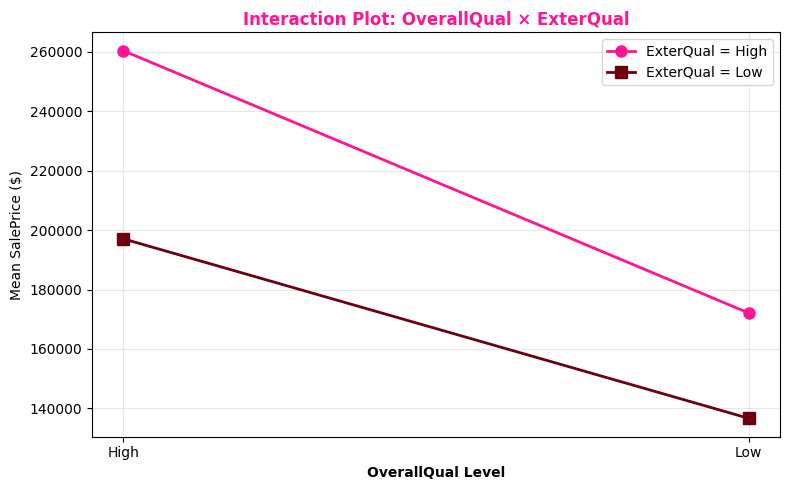

In [62]:
# --- Interaction Plot: OverallQual × ExterQual ---
fig, ax = plt.subplots(figsize=(8, 5))

for level, color, marker in [("High", pink_dark, 'o'), ("Low", pink_accent, 's')]:
    means = df[df["B_ExterQual"] == level].groupby("A_OverallQual")["SalePrice"].mean()
    ax.plot(means.index, means.values, marker=marker, color=color,
            linewidth=2, markersize=8, label=f'ExterQual = {level}')

ax.set_xlabel("OverallQual Level", fontweight='bold')
ax.set_ylabel("Mean SalePrice ($)")
ax.set_title("Interaction Plot: OverallQual × ExterQual", fontweight='bold', color=pink_dark)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

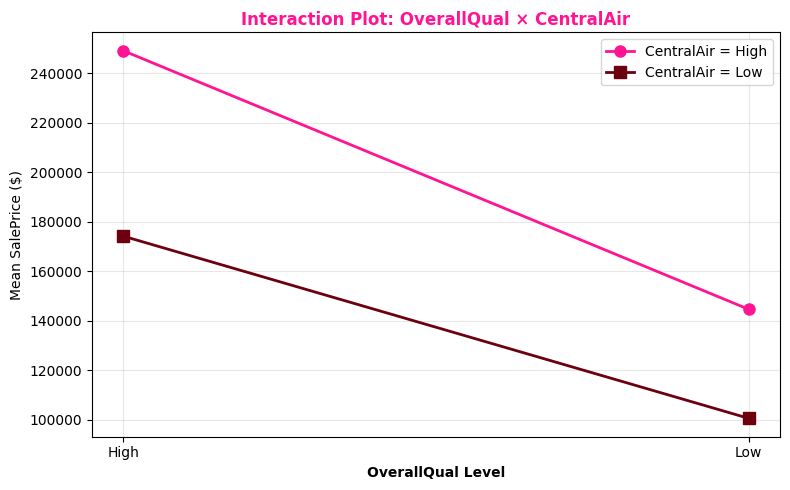

In [63]:
# --- Interaction Plot: OverallQual × CentralAir ---
fig, ax = plt.subplots(figsize=(8, 5))

for level, color, marker in [("High", pink_dark, 'o'), ("Low", pink_accent, 's')]:
    means = df[df["C_CentralAir"] == level].groupby("A_OverallQual")["SalePrice"].mean()
    ax.plot(means.index, means.values, marker=marker, color=color,
            linewidth=2, markersize=8, label=f'CentralAir = {level}')

ax.set_xlabel("OverallQual Level", fontweight='bold')
ax.set_ylabel("Mean SalePrice ($)")
ax.set_title("Interaction Plot: OverallQual × CentralAir", fontweight='bold', color=pink_dark)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

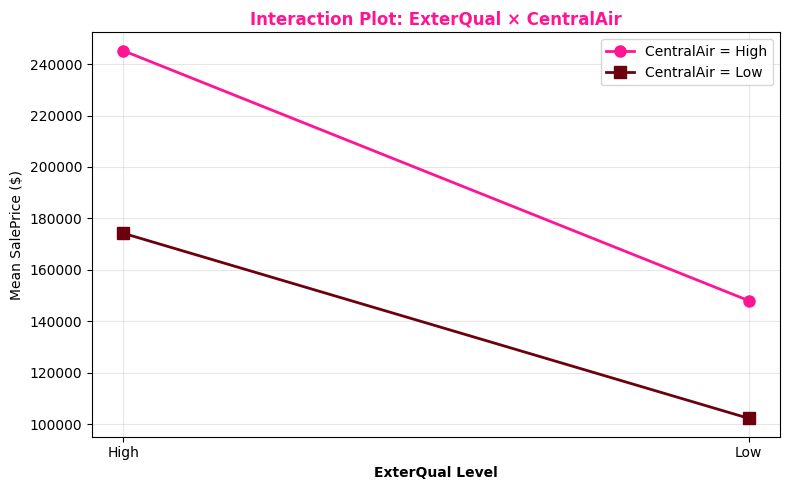

In [64]:
# --- Interaction Plot: ExterQual × CentralAir ---
fig, ax = plt.subplots(figsize=(8, 5))

for level, color, marker in [("High", pink_dark, 'o'), ("Low", pink_accent, 's')]:
    means = df[df["C_CentralAir"] == level].groupby("B_ExterQual")["SalePrice"].mean()
    ax.plot(means.index, means.values, marker=marker, color=color,
            linewidth=2, markersize=8, label=f'CentralAir = {level}')

ax.set_xlabel("ExterQual Level", fontweight='bold')
ax.set_ylabel("Mean SalePrice ($)")
ax.set_title("Interaction Plot: ExterQual × CentralAir", fontweight='bold', color=pink_dark)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Summary of Factorial Effects
         Effect        Type  Effect Size ($)
A (OverallQual)        Main    108000.622663
  B (ExterQual)        Main    101219.840459
 C (CentralAir)        Main     80922.636206
          A × B Interaction     13938.189816
          A × C Interaction     15443.801799
          B × C Interaction     12615.512540


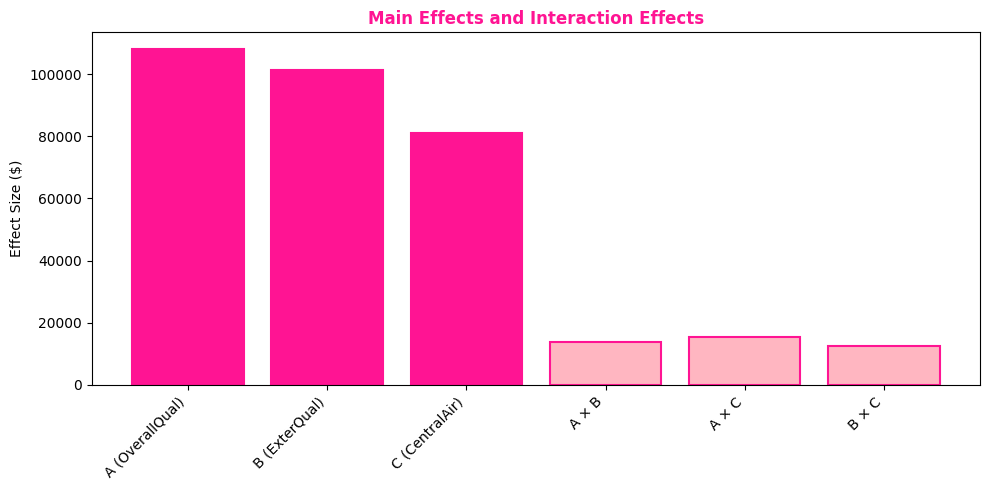

In [65]:
# --- Summary of all effects ---
print("=" * 60)
print("Summary of Factorial Effects")
print("=" * 60)

effects_summary = pd.DataFrame({
    "Effect": ["A (OverallQual)", "B (ExterQual)", "C (CentralAir)",
               "A × B", "A × C", "B × C"],
    "Type": ["Main", "Main", "Main", "Interaction", "Interaction", "Interaction"],
    "Effect Size ($)": [main_A, main_B, main_C, interaction_AB, interaction_AC, interaction_BC]
})
print(effects_summary.to_string(index=False))

# Bar chart of effects
fig, ax = plt.subplots(figsize=(10, 5))
colors = [pink_dark]*3 + [pink_light]*3
bars = ax.bar(effects_summary["Effect"], effects_summary["Effect Size ($)"],
              color=colors, edgecolor=pink_dark, linewidth=1.5)
ax.set_ylabel("Effect Size ($)")
ax.set_title("Main Effects and Interaction Effects", fontweight='bold', color=pink_dark)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## Part 4: Parametric Regression

Build a regression model using only the **significant ordinal features** identified by ANOVA (Part 2) plus the **2 numerical features**: `GrLivArea` and `TotalBsmtSF`.

**Tasks:**
- Encode ordinal features numerically (map quality levels to integers)
- Fit a linear regression model (OLS)
- Analyze the model: R², coefficient significance, residual plots
- Optionally try regularized regression (Ridge, Lasso) and compare
- Apply ANOVA on the regression model to assess factor contributions

---
## Part 5: Non-Parametric Model (Neural Network)

Build a neural network regression model using **all** available features to predict SalePrice. This is also the model that produces your `submission.csv` for Kaggle scoring.

**Tasks:**
- Preprocess all features: handle missing values, encode categoricals, scale numerics
- Build and train a neural network (e.g. `sklearn.neural_network.MLPRegressor` or PyTorch)
- Evaluate on training data (RMSE, R²) and analyze residuals
- Generate predictions for the test set and save as `submission.csv`

**Important:** The Kaggle RMSE score is evaluated on the predictions from this model.